### Notebook Execution Order

- To ensure the project runs correctly, you have to make sure that the notebook `23127130_23127168_23127231_23127238_23127269.ipynb` **MUST** be run first, because it performs the dataset merging and preparation steps required for the other notebooks.

- After that, the remaining notebooks can be run, but to follow the order of the Objective, you should run like this order:
    1. `23127130_23127168_23127231_23127238_23127269.ipynb`
    2. `23127130_23127238.ipynb`
    3. `23127168.ipynb`
    4. `23127231_23127269.ipynb`

### YouTube Presentation

- Presentation video link: [YouTube link](YOUR_YOUTUBE_LINK_HERE)


## Task Assignment

This notebook was completed by two team members working on the `Education` topic, with 5 analysis objectives as follows:

1. Tracking trends in basic educational access through enrollment and out-of-school rates
2. Government financial commitment and its relationship with educational access
3. Gender disparity in educational access across different levels of education
4. Monitoring youth literacy rates and gender disparities in foundational learning outcomes
5. Long-term educational attainment and gender disparities among the adult population

Based on that, we divided the work as follows:

| Student ID | Full Name | Task |
|------------|-----------|------|
| 23127130 | Nguyễn Hữu Anh Trí | Completed Objectives 1 to 3 |
| 23127238 | Trần Hoài Thiện Nhân | Completed Objectives 4 to 5 |


In [43]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

- Loading dataset


In [44]:
data = pd.read_csv("SoutheastAsianData.csv")


## Subgroup: Education

#### Objective 1: Tracking trends in basic educational access through enrollment and out-of-school rates

- **Question**  
How have the out-of-school rates for primary- and lower-secondary-school-age children changed over time? Do these trends differ across countries?

- **Data fields**  
    - `Children out of school (% of primary school age)`: percentage of primary-school-age children who are not enrolled in any school, used to measure exclusion at the primary level.  
    - `Adolescents out of school (% of lower secondary school age)`: percentage of lower-secondary-school-age adolescents who are not enrolled in school, used to measure exclusion at the lower-secondary level.  
    - `School enrollment, primary (% net)`: percentage of official primary-school-age children who are enrolled in school, used to measure inclusion at the primary level.  
    - `School enrollment, secondary (% net)`: percentage of official secondary-school-age children who are enrolled in school, used to measure inclusion at the secondary level.  
    - `Year`: used to identify the timeline of changes.  
    - `Country Name`: used to compare trends across countries.


In [45]:
SEA_COUNTRIES = [
    "Brunei Darussalam",
    "Cambodia",
    "Indonesia",
    "Lao PDR",
    "Malaysia",
    "Myanmar",
    "Philippines",
    "Singapore",
    "Thailand",
    "Timor-Leste",
    "Viet Nam",
]

OBJ1_COLS = {
    "primary_enroll": "School enrollment, primary (% net)",
    "primary_out": "Children out of school (% of primary school age)",
    "secondary_enroll": "School enrollment, secondary (% net)",
    "secondary_out": "Adolescents out of school (% of lower secondary school age)",
}

In [46]:
obj1_df = data.loc[data["Country Name"].isin(SEA_COUNTRIES), ["Country Name", "Year"] + list(OBJ1_COLS.values())].copy()
obj1_df["Year"] = pd.to_numeric(obj1_df["Year"], errors="coerce")

for col in OBJ1_COLS.values():
    obj1_df[col] = pd.to_numeric(obj1_df[col], errors="coerce")

obj1_df = obj1_df[obj1_df["Year"].between(2000, 2020)].copy()

obj1_yearly = obj1_df.groupby("Year", as_index=True)[list(OBJ1_COLS.values())].mean(numeric_only=True)


- **Chart type**  
    - **Dual-line chart (or panel line charts)**, with `Year` on the x-axis and the corresponding enrollment and out-of-school rates on the y-axis. This chart type is appropriate because it clearly visualizes the inverse relationship between the two indicators over time: net enrollment is expected to increase while out-of-school rates decline.
    - **Slope chart**, comparing each country's out-of-school rates between **2000** and **2020**. This chart type is suitable because it clearly shows the **direction** and **magnitude** of change for each country by connecting the starting and ending values with a single line. 

- **Expected insight** This analysis helps reveal whether access to basic education has improved over time, whether exclusion from school has decreased, and whether these patterns vary by country. By combining enrollment and out-of-school indicators, it provides a more complete picture of educational inclusion and exclusion.

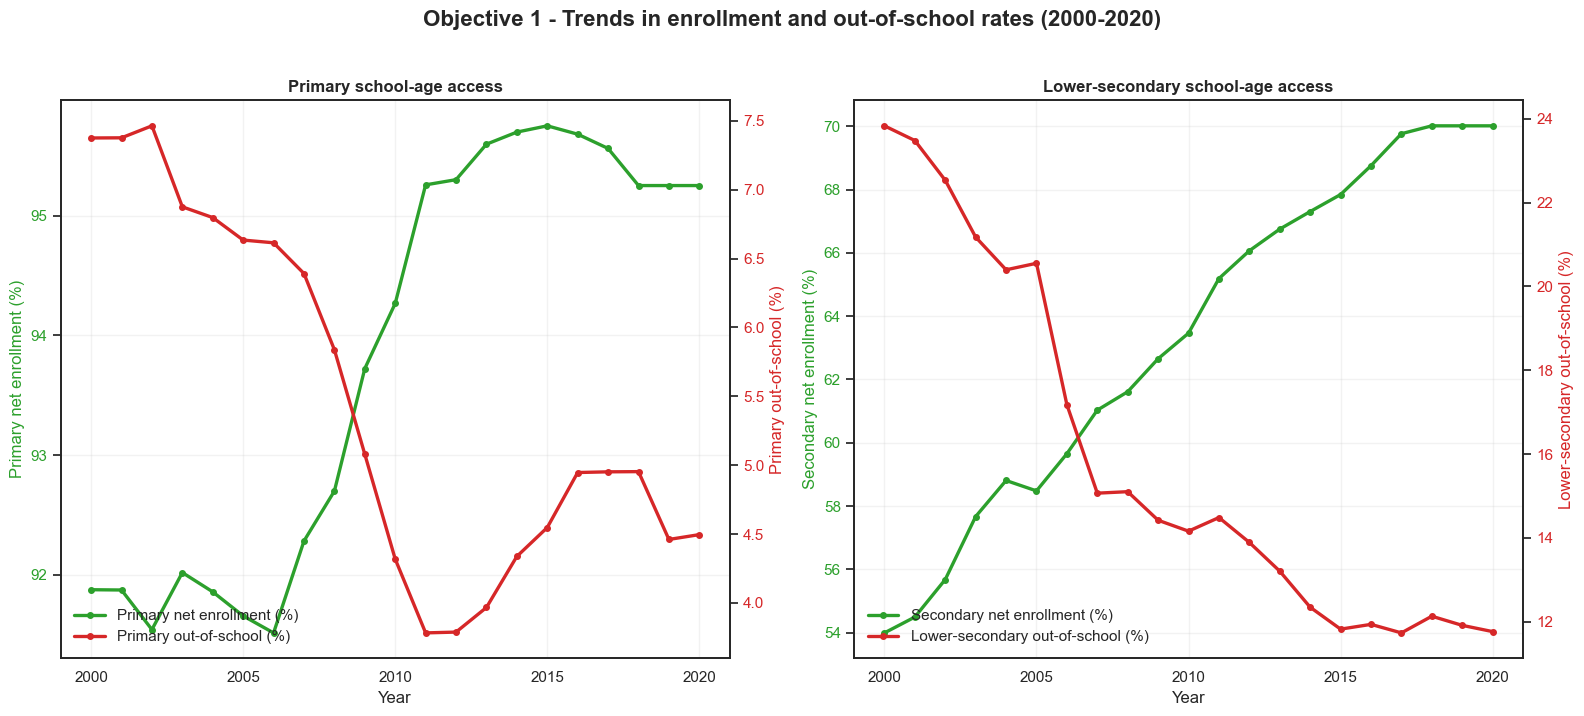

In [47]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7), sharex=True)

line_specs = [
    (
        "Primary school-age access",
        OBJ1_COLS["primary_enroll"],
        OBJ1_COLS["primary_out"],
        "Primary net enrollment (%)",
        "Primary out-of-school (%)",
    ),
    (
        "Lower-secondary school-age access",
        OBJ1_COLS["secondary_enroll"],
        OBJ1_COLS["secondary_out"],
        "Secondary net enrollment (%)",
        "Lower-secondary out-of-school (%)",
    ),
]

for ax, (title, enroll_col, out_col, enroll_label, out_label) in zip(axes, line_specs):
    ax.plot(
        obj1_yearly.index,
        obj1_yearly[enroll_col],
        color="#2ca02c",
        linewidth=2.4,
        marker="o",
        markersize=4,
        label=enroll_label,
    )
    ax.set_title(title, fontsize=12, weight="bold")
    ax.set_xlabel("Year")
    ax.set_ylabel(enroll_label, color="#2ca02c")
    ax.tick_params(axis="y", labelcolor="#2ca02c")
    ax.grid(alpha=0.25)

    ax2 = ax.twinx()
    ax2.plot(
        obj1_yearly.index,
        obj1_yearly[out_col],
        color="#d62728",
        linewidth=2.4,
        marker="o",
        markersize=4,
        label=out_label,
    )
    ax2.set_ylabel(out_label, color="#d62728")
    ax2.tick_params(axis="y", labelcolor="#d62728")

    lines_1, labels_1 = ax.get_legend_handles_labels()
    lines_2, labels_2 = ax2.get_legend_handles_labels()
    ax.legend(lines_1 + lines_2, labels_1 + labels_2, loc="lower left", frameon=False)

for ax in axes:
    ax.set_xticks(range(2000, 2021, 5))

fig.suptitle(
    "Objective 1 - Trends in enrollment and out-of-school rates (2000-2020)",
    fontsize=16,
    weight="bold",
    y=1.02,
)
plt.tight_layout()
plt.show()

- **Overview analysis:**
  - From 2000 to 2020, Southeast Asia showed clear improvement in basic educational access at both the primary and lower-secondary levels.
  - The charts reveal a strong inverse relationship between **net enrollment rates** and **out-of-school rates**: as enrollment increased, the share of children and adolescents outside the school system declined.
  - The improvement was more visible at the **lower-secondary level**, where changes were larger and more consistent over time.

- **Observations and trends drawn from the data:**
  - At the **primary level**, net enrollment remained relatively high throughout the period and began to rise more clearly after 2007, reaching a stable high level after 2011.
  - Over the same period, the **primary out-of-school rate** declined noticeably, indicating that more children of primary-school age were being successfully included in the education system.
  - At the **lower-secondary level**, the upward trend in net enrollment was even stronger, increasing from roughly **54% to around 70%** over the period.
  - Meanwhile, the **lower-secondary out-of-school rate** fell sharply from nearly **24% to about 12%**, showing substantial progress in expanding access for adolescents.
  - Compared with primary education, secondary education experienced a larger overall shift, suggesting that the region made stronger gains in reducing exclusion at this level.

- **Conclusion:**
  - Overall, the figure suggests that Southeast Asia achieved better educational access between 2000 and 2020.
  - This progress is reflected in the combined pattern of **rising enrollment** and **falling out-of-school rates** at both education levels.
  - The results also suggest that regional efforts to improve school participation were especially effective in **lower-secondary education**.


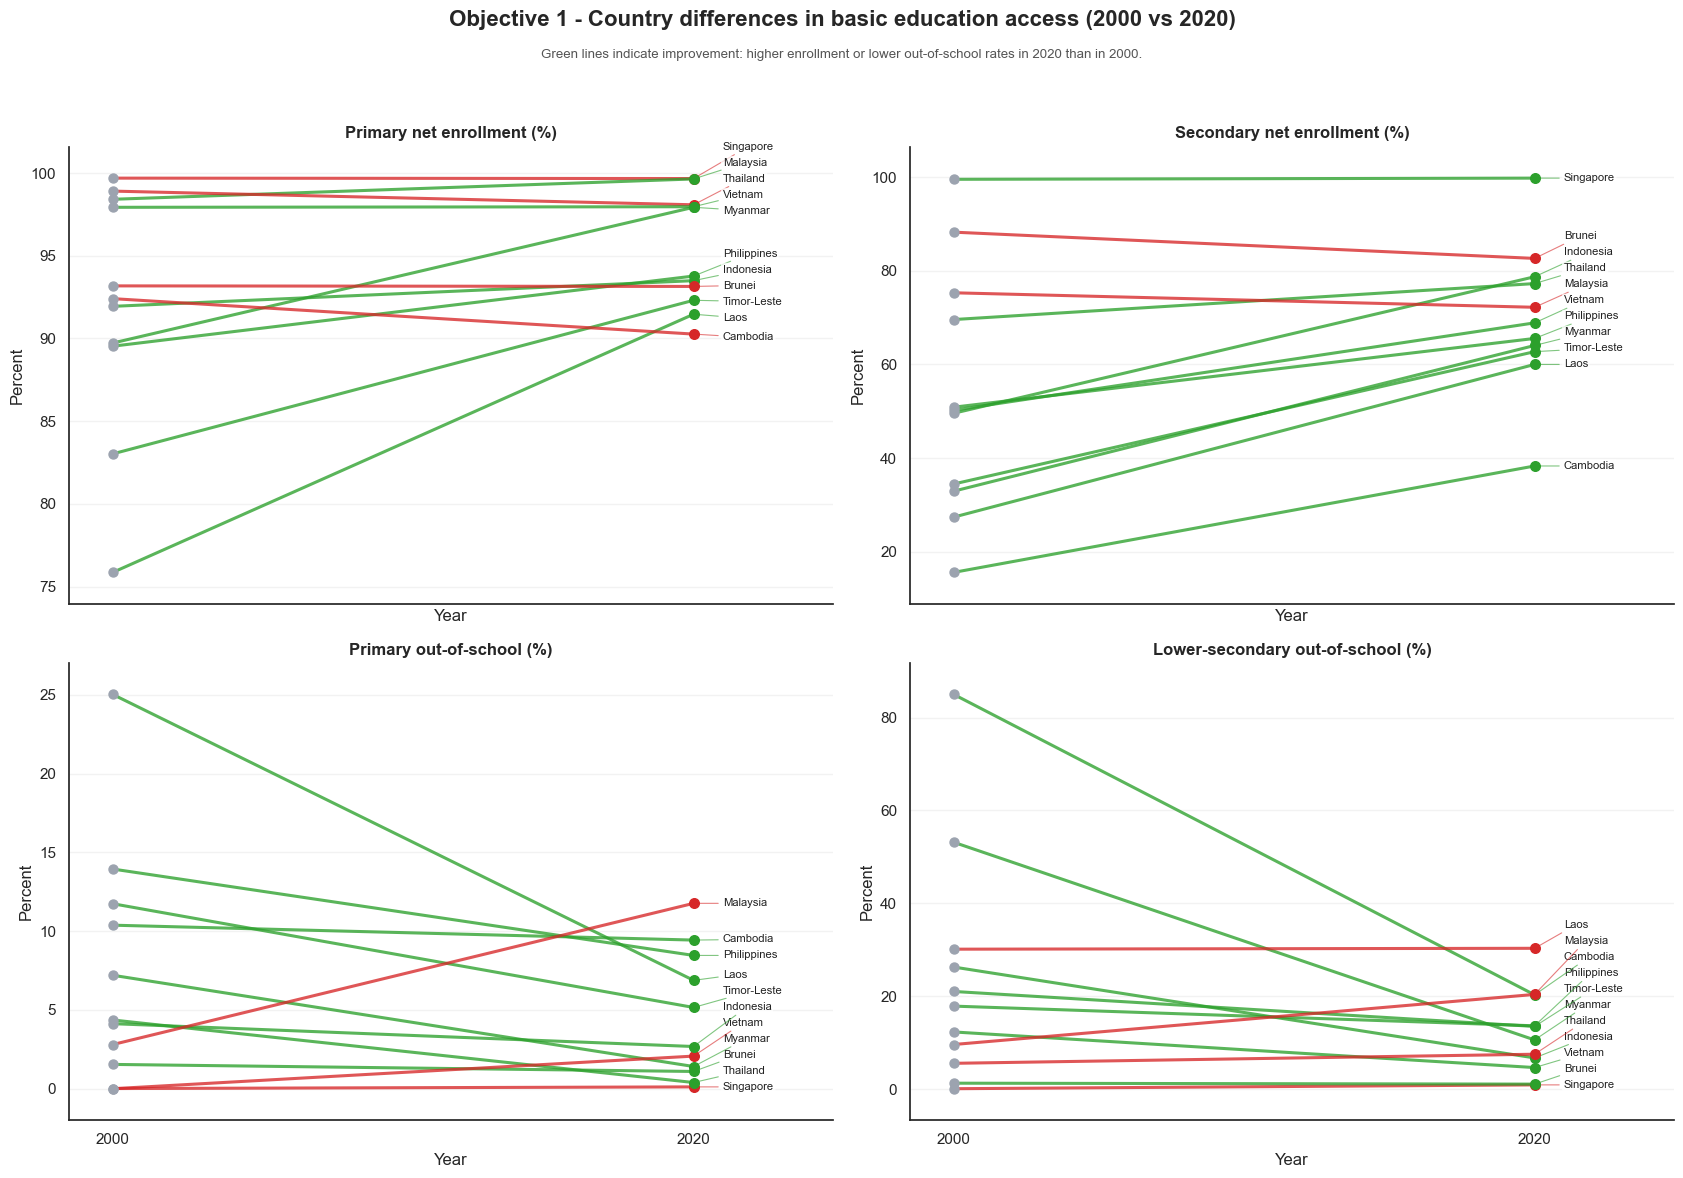

In [48]:
slope_specs = [
    {
        "key": "primary_enroll",
        "title": "Primary net enrollment (%)",
        "better": "up",
    },
    {
        "key": "secondary_enroll",
        "title": "Secondary net enrollment (%)",
        "better": "up",
    },
    {
        "key": "primary_out",
        "title": "Primary out-of-school (%)",
        "better": "down",
    },
    {
        "key": "secondary_out",
        "title": "Lower-secondary out-of-school (%)",
        "better": "down",
    },
]

label_map = {
    "Brunei Darussalam": "Brunei",
    "Lao PDR": "Laos",
    "Viet Nam": "Vietnam",
}

slope_metric_cols = [OBJ1_COLS[spec["key"]] for spec in slope_specs]

slope_df = data.loc[
    data["Country Name"].isin(SEA_COUNTRIES),
    ["Country Name", "Year"] + slope_metric_cols,
].copy()

slope_df["Year"] = pd.to_numeric(slope_df["Year"], errors="coerce")

for col in slope_metric_cols:
    slope_df[col] = pd.to_numeric(slope_df[col], errors="coerce")

slope_df = slope_df[slope_df["Year"].isin([2000, 2020])].copy()

def make_slope_table(metric_col, better):
    table = (
        slope_df.pivot_table(index="Country Name", columns="Year", values=metric_col, aggfunc="mean")
        .dropna(subset=[2000, 2020])
        .reset_index()
    )
    sort_ascending = better == "down"
    return table.sort_values(2020, ascending=sort_ascending).reset_index(drop=True)

def spread_label_positions(values, lower, upper, min_gap):
    if len(values) == 0:
        return []

    order = np.argsort(values)
    sorted_vals = np.array(values, dtype=float)[order].copy()
    adjusted = sorted_vals.copy()

    adjusted[0] = max(adjusted[0], lower)
    for i in range(1, len(adjusted)):
        adjusted[i] = max(adjusted[i], adjusted[i - 1] + min_gap)

    overflow = adjusted[-1] - upper
    if overflow > 0:
        adjusted -= overflow

    adjusted[0] = max(adjusted[0], lower)
    for i in range(1, len(adjusted)):
        adjusted[i] = max(adjusted[i], adjusted[i - 1] + min_gap)

    if adjusted[-1] > upper:
        adjusted[-1] = upper
        for i in range(len(adjusted) - 2, -1, -1):
            adjusted[i] = min(adjusted[i], adjusted[i + 1] - min_gap)
        if adjusted[0] < lower:
            shift = lower - adjusted[0]
            adjusted += shift

    result = np.empty_like(adjusted)
    result[order] = adjusted
    return result.tolist()

fig, axes = plt.subplots(2, 2, figsize=(17, 12), sharex=True)
axes = axes.flatten()
fig.patch.set_facecolor("white")

for ax, spec in zip(axes, slope_specs):
    metric_col = OBJ1_COLS[spec["key"]]
    plot_df = make_slope_table(metric_col, spec["better"])

    y_min = min(plot_df[2000].min(), plot_df[2020].min())
    y_max = max(plot_df[2000].max(), plot_df[2020].max())
    y_pad = (y_max - y_min) * 0.08 if y_max > y_min else 1
    lower = y_min - y_pad
    upper = y_max + y_pad
    min_gap = max((upper - lower) * 0.035, 0.6)
    label_y_positions = spread_label_positions(plot_df[2020].tolist(), lower, upper, min_gap)

    for (_, row), label_y in zip(plot_df.iterrows(), label_y_positions):
        start = row[2000]
        end = row[2020]
        country = row["Country Name"]
        short_name = label_map.get(country, country)

        improved = (end >= start) if spec["better"] == "up" else (end <= start)
        line_color = "#2ca02c" if improved else "#d62728"

        ax.plot([2000, 2020], [start, end], color=line_color, linewidth=2.2, alpha=0.78)
        ax.scatter(2000, start, color="#9ca3af", s=42, zorder=3)
        ax.scatter(2020, end, color=line_color, s=48, zorder=3)

        ax.annotate(
            short_name,
            xy=(2020, end),
            xytext=(2021.0, label_y),
            textcoords="data",
            va="center",
            fontsize=8.1,
            color="#222222",
            bbox=dict(boxstyle="round,pad=0.15", fc="white", ec="none", alpha=0.75),
            arrowprops=dict(arrowstyle="-", color=line_color, lw=0.8, alpha=0.6),
        )

    ax.set_title(spec["title"], fontsize=12, weight="bold")
    ax.set_xlim(1998.5, 2024.8)
    ax.set_ylim(lower, upper)
    ax.set_xticks([2000, 2020])
    ax.set_xlabel("Year")
    ax.set_ylabel("Percent")
    ax.grid(axis="y", alpha=0.25)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

fig.suptitle(
    "Objective 1 - Country differences in basic education access (2000 vs 2020)",
    fontsize=16,
    weight="bold",
    y=0.98,
)

fig.text(
    0.5,
    0.94,
    "Green lines indicate improvement: higher enrollment or lower out-of-school rates in 2020 than in 2000.",
    ha="center",
    fontsize=9.5,
    color="#555555",
)

plt.tight_layout(rect=(0, 0, 1, 0.93))
plt.show()


- **Overview analysis:**
  - The slope charts show that most Southeast Asian countries improved their access to basic education between **2000 and 2020**.
  - At the **primary level**, changes are generally smaller because many countries had already reached very high enrollment rates by 2000.
  - At the **lower-secondary level**, the improvement is much more visible, with stronger increases in enrollment and clearer reductions in out-of-school rates.
  - However, the gap between stronger-performing countries and lower-performing countries still remains.

- **Observations and trends drawn from the data:**
  - The **strong-performing group** includes countries such as **Singapore** and **Thailand**, which remain near the top in enrollment and among the lowest in out-of-school rates. These countries show that basic education access was already strong in 2000 and remained strong in 2020.
  - A **high but relatively stable group** includes countries where primary enrollment was already close to universal in 2000, so the slope is flatter. In these cases, the charts suggest maintenance of strong performance rather than dramatic improvement.
  - The **largest improvement group** includes countries such as **Cambodia, Lao PDR, Timor-Leste, and Myanmar**, especially at the lower-secondary level. These countries show steeper upward slopes in enrollment or stronger downward slopes in out-of-school rates, indicating meaningful progress over the 20-year period.
  - Despite these gains, some of these countries still remain below the regional leaders in 2020, meaning that improvement has occurred but equality in access has not yet been achieved.
  - A **mixed-results group** can also be observed, where a country improves in one indicator but shows weaker progress in another. This suggests that educational access does not improve evenly across all levels and measures.

- **Conclusion:**
  - Overall, the slope charts confirm that **basic education access improved across most Southeast Asian countries** from 2000 to 2020.
  - Progress is **more noticeable at the lower-secondary level** than at the primary level, where many countries were already performing well.
  - The region is moving in a positive direction, but **cross-country differences remain clear**, so educational access is improving without yet becoming fully equal across Southeast Asia.


#### Objective 2: Government financial commitment and its relationship with educational access

- **Question** Does higher financial commitment automatically lead to better primary and secondary educational access, or do some countries achieve stronger outcomes with lower levels of spending?

- **Data fields**  
    - `Government expenditure on education, total (% of GDP)`: measures public education spending relative to the size of the economy, allowing comparison of national investment effort across countries.  
    - `Government expenditure on education, total (% of government expenditure)`: measures the share of the government budget allocated to education, showing how strongly education is prioritized in public spending.  
    - `School enrollment, primary (% net)`: percentage of official primary-school-age children enrolled in school, used as a positive indicator of access.  
    - `Children out of school (% of primary school age)`: percentage of primary-school-age children not enrolled in school, used as a negative indicator of access.  
    - `School enrollment, secondary (% net)`: percentage of official secondary-school-age children enrolled in school, used to evaluate access at the secondary level.  
    - `Adolescents out of school (% of lower secondary school age)`: percentage of lower-secondary-school-age adolescents not enrolled in school, used as a negative measure of access at the secondary level.


In [49]:
OBJ2_COLS = {
    "govt_gdp": "Government expenditure on education, total (% of GDP)",
    "govt_total": "Government expenditure on education, total (% of government expenditure)",
    "primary_enroll": "School enrollment, primary (% net)",
    "primary_out": "Children out of school (% of primary school age)",
    "secondary_enroll": "School enrollment, secondary (% net)",
    "secondary_out": "Adolescents out of school (% of lower secondary school age)",
}

In [50]:
sns.set_theme(style="whitegrid", context="notebook")

label_map = {
    "Brunei Darussalam": "Brunei",
    "Lao PDR": "Laos",
    "Viet Nam": "Vietnam",
}

obj2_df = data.loc[
    data["Country Name"].isin(SEA_COUNTRIES),
    ["Country Name", "Year"] + list(OBJ2_COLS.values()),
].copy()

obj2_df["Year"] = pd.to_numeric(obj2_df["Year"], errors="coerce")

for col in OBJ2_COLS.values():
    obj2_df[col] = pd.to_numeric(obj2_df[col], errors="coerce")

obj2_df = obj2_df[obj2_df["Year"].between(2000, 2020)].copy()
obj2_df["Country Label"] = obj2_df["Country Name"].replace(label_map)


- **Chart type**  Correlation heatmap. This chart type is suitable because it displays the relationship between financial input variables and educational outcome variables in a compact and intuitive way. By using color intensity to represent the strength and direction of correlation, it allows the audience to quickly assess whether higher government spending is associated with higher enrollment and lower out-of-school rates.

- **Expected insight**  This analysis is expected to show whether stronger financial commitment to education is consistently linked to better educational access across Southeast Asia.

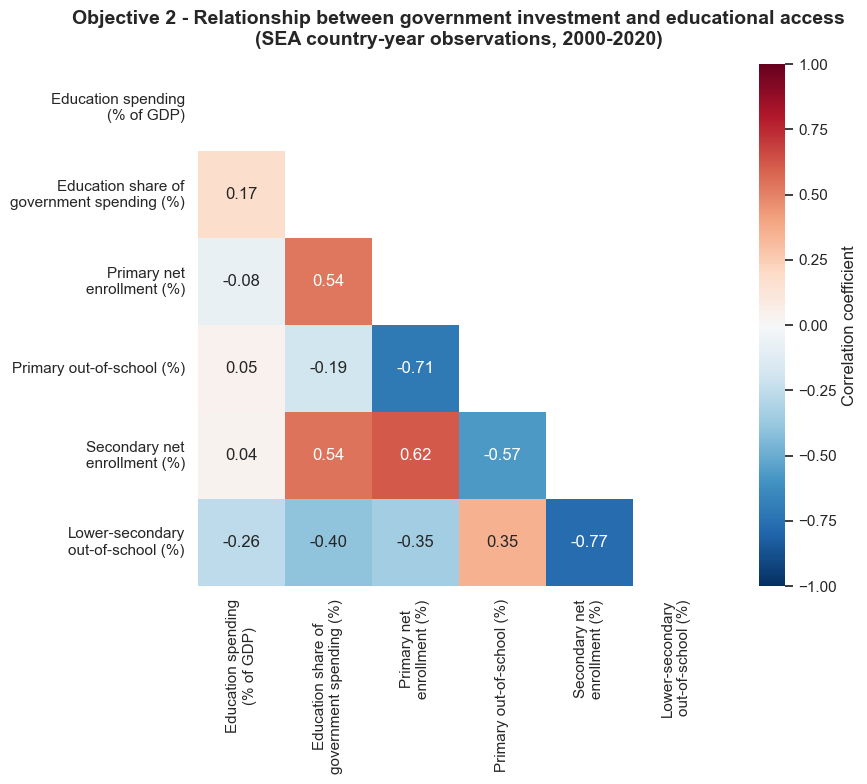

In [51]:
# Chart A: Correlation heatmap between government investment and educational access

import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

sns.set_theme(style="white", context="notebook")

heat_cols = [
    OBJ2_COLS["govt_gdp"],
    OBJ2_COLS["govt_total"],
    OBJ2_COLS["primary_enroll"],
    OBJ2_COLS["primary_out"],
    OBJ2_COLS["secondary_enroll"],
    OBJ2_COLS["secondary_out"],
]

obj2_heat_df = data.loc[
    data["Country Name"].isin(SEA_COUNTRIES),
    ["Country Name", "Year"] + heat_cols,
].copy()

obj2_heat_df["Year"] = pd.to_numeric(obj2_heat_df["Year"], errors="coerce")

for col in heat_cols:
    obj2_heat_df[col] = pd.to_numeric(obj2_heat_df[col], errors="coerce")

obj2_heat_df = obj2_heat_df[obj2_heat_df["Year"].between(2000, 2020)].copy()

corr_df = obj2_heat_df[heat_cols].corr(method="pearson")

label_map = {
    OBJ2_COLS["govt_gdp"]: "Education spending\n(% of GDP)",
    OBJ2_COLS["govt_total"]: "Education share of\ngovernment spending (%)",
    OBJ2_COLS["primary_enroll"]: "Primary net\nenrollment (%)",
    OBJ2_COLS["primary_out"]: "Primary out-of-school (%)",
    OBJ2_COLS["secondary_enroll"]: "Secondary net\nenrollment (%)",
    OBJ2_COLS["secondary_out"]: "Lower-secondary\nout-of-school (%)",
}

corr_df = corr_df.rename(index=label_map, columns=label_map)

mask = np.triu(np.ones_like(corr_df, dtype=bool))

fig, ax = plt.subplots(figsize=(10, 8))
ax.grid(False)

sns.heatmap(
    corr_df,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    vmin=-1,
    vmax=1,
    center=0,
    square=True,
    linewidths=0,
    cbar_kws={"label": "Correlation coefficient"},
    ax=ax,
)

ax.set_title(
    "Objective 2 - Relationship between government investment and educational access\n"
    "(SEA country-year observations, 2000-2020)",
    fontsize=14,
    weight="bold",
    pad=14,
)

ax.set_facecolor("white")

plt.tight_layout()
plt.show()


- **Overview analysis:**
  - The heatmap suggests that **education’s share of total government spending** is more closely related to educational access than **education spending as a share of GDP**.
  - The clearest patterns are the inverse relationships between **enrollment** and **out-of-school rates**, especially within the same education level.
  - Since this chart is based on **SEA country-year observations (2000-2020)**, it shows correlation patterns across the dataset, not direct causation.

- **Observations and trends drawn from the data:**
  - The strongest inverse relationship appears between **secondary net enrollment** and **lower-secondary out-of-school rates** (`-0.77`), showing that countries or years with better secondary access tend to have much lower exclusion at the lower-secondary level.
  - A similarly strong inverse relationship exists between **primary net enrollment** and **primary out-of-school rates** (`-0.71`), confirming the same pattern at the primary level.
  - **Education share of government spending (%)** has a **moderate positive correlation** with both **primary net enrollment** (`0.54`) and **secondary net enrollment** (`0.54`). This suggests that when education receives a larger share of the public budget, access outcomes tend to be better.
  - The same budget-priority indicator is **moderately negatively correlated** with **lower-secondary out-of-school rates** (`-0.40`), meaning stronger budget prioritization is generally associated with lower exclusion at the secondary level.
  - However, its relationship with **primary out-of-school rates** is weaker (`-0.19`), so the connection between spending priority and exclusion is less clear at the primary level.
  - In contrast, **education spending as a share of GDP** has **very weak correlations** with most access indicators:
    - with **primary net enrollment**: `-0.08`
    - with **primary out-of-school**: `0.05`
    - with **secondary net enrollment**: `0.04`
    - with **lower-secondary out-of-school**: `-0.26`
  - This means that spending relative to GDP alone does **not strongly explain** differences in enrollment or exclusion across the dataset.
  - There is also a **moderate positive correlation** between **primary net enrollment** and **secondary net enrollment** (`0.62`), suggesting that countries performing well at one level often also perform well at the other.
  - In addition, **primary out-of-school** and **lower-secondary out-of-school** are **positively correlated** (`0.35`), meaning countries with more exclusion at one level often also face exclusion at the other level.

- **Conclusion:**
  - Overall, the heatmap indicates that **how strongly governments prioritize education within their budgets** is more closely associated with educational access than **how much they spend relative to GDP**.
  - Better access is reflected in **higher enrollment** and **lower out-of-school rates**, with the strongest relationship appearing at the **secondary level**.
  - Therefore, the chart suggests that **budget prioritization may matter more than overall GDP-based spending levels**, although these are correlations and should not be interpreted as proof of causation.


#### Objective 3: Gender disparity in educational access across different levels of education

- **Question**  
  At which educational level, primary, secondary, or tertiary, does the gender gap appear the strongest? Are there specific countries that achieve gender parity at foundational levels but experience significant disparities at higher education levels?

- **Data fields**  
  - `School enrollment, primary, female (% net)`: percentage of official primary-school-age girls enrolled in primary school, used to compare female participation at the primary level.  
  - `School enrollment, primary, male (% net)`: percentage of official primary-school-age boys enrolled in primary school, used to compare male participation at the primary level.  
  - `School enrollment, secondary, female (% net)`: percentage of official secondary-school-age girls enrolled in secondary school, used to compare female participation at the secondary level.  
  - `School enrollment, secondary, male (% net)`: percentage of official secondary-school-age boys enrolled in secondary school, used to compare male participation at the secondary level.  
  - `School enrollment, tertiary, female (% gross)`: gross tertiary enrollment rate for females, used to capture women’s participation in higher education.  
  - `School enrollment, tertiary, male (% gross)`: gross tertiary enrollment rate for males, used to capture men’s participation in higher education.  
  - `School enrollment, primary (gross), gender parity index (GPI)`: ratio of female-to-male enrollment at the primary level, where `1` indicates parity.  
  - `School enrollment, secondary (gross), gender parity index (GPI)`: ratio of female-to-male enrollment at the secondary level, used to evaluate gender balance in secondary education.  
  - `School enrollment, tertiary (gross), gender parity index (GPI)`: ratio of female-to-male enrollment at the tertiary level, used to identify whether gender disparity becomes stronger in higher education.


In [52]:
SELECTED_YEARS = [2000, 2020]

OBJ3_COLS = {
    "primary_female": "School enrollment, primary, female (% net)",
    "primary_male": "School enrollment, primary, male (% net)",
    "secondary_female": "School enrollment, secondary, female (% net)",
    "secondary_male": "School enrollment, secondary, male (% net)",
    "tertiary_female": "School enrollment, tertiary, female (% gross)",
    "tertiary_male": "School enrollment, tertiary, male (% gross)",
    "primary_gpi": "School enrollment, primary (gross), gender parity index (GPI)",
    "secondary_gpi": "School enrollment, secondary (gross), gender parity index (GPI)",
    "tertiary_gpi": "School enrollment, tertiary (gross), gender parity index (GPI)",
}

obj3_df = data[data["Country Name"].isin(SEA_COUNTRIES)].copy()
obj3_df["Year"] = pd.to_numeric(obj3_df["Year"], errors="coerce")

for col in OBJ3_COLS.values():
    obj3_df[col] = pd.to_numeric(obj3_df[col], errors="coerce")

display_names = {
    "Brunei Darussalam": "Brunei",
    "Lao PDR": "Laos",
    "Viet Nam": "Vietnam",
}
country_order = [display_names.get(country, country) for country in SEA_COUNTRIES]

obj3_selected = obj3_df.loc[
    obj3_df["Year"].isin(SELECTED_YEARS),
    ["Country Name", "Year"] + list(OBJ3_COLS.values()),
].copy()

obj3_selected["Country"] = obj3_selected["Country Name"].replace(display_names)
obj3_selected["Country"] = pd.Categorical(
    obj3_selected["Country"],
    categories=country_order,
    ordered=True,
)

- **Chart type**  
  - **Dumbbell plot**: suitable for visualizing the absolute enrollment gap between males and females at each education level in a specific year. By placing male and female enrollment rates on the same axis and connecting them with a line, the chart makes the size and direction of the gender gap immediately visible for each country.  
  - **Grouped bar chart**: suitable for comparing the Gender Parity Index across primary, secondary, and tertiary education for each country. With a reference line at `1.0`, this chart helps highlight whether countries maintain gender balance across all levels or begin to show disparity at higher levels.

- **Expected insight**  
  This analysis is expected to reveal at which education level gender inequality is most pronounced across Southeast Asian countries. It can also show whether some countries achieve near parity in primary and secondary education but experience a wider gender gap in tertiary education, helping identify where gender equality in access is maintained and where it begins to weaken.

- **Note on missing values**  
  Some countries were excluded from parts of the analysis because the required indicators contain too many missing values.  
  - **Excluded from primary-level enrollment comparison**: `Brunei Darussalam`, `Singapore`, and `Viet Nam`, because both `School enrollment, primary, female (% net)` and `School enrollment, primary, male (% net)` are missing for the full period `2000-2020`.  
  - **Use caution for Viet Nam in secondary-level analysis**: `School enrollment, secondary, female (% net)` and `School enrollment, secondary (gross), gender parity index (GPI)` for `Viet Nam` were imputed for the full period `2000-2020`, so related results should be interpreted carefully.

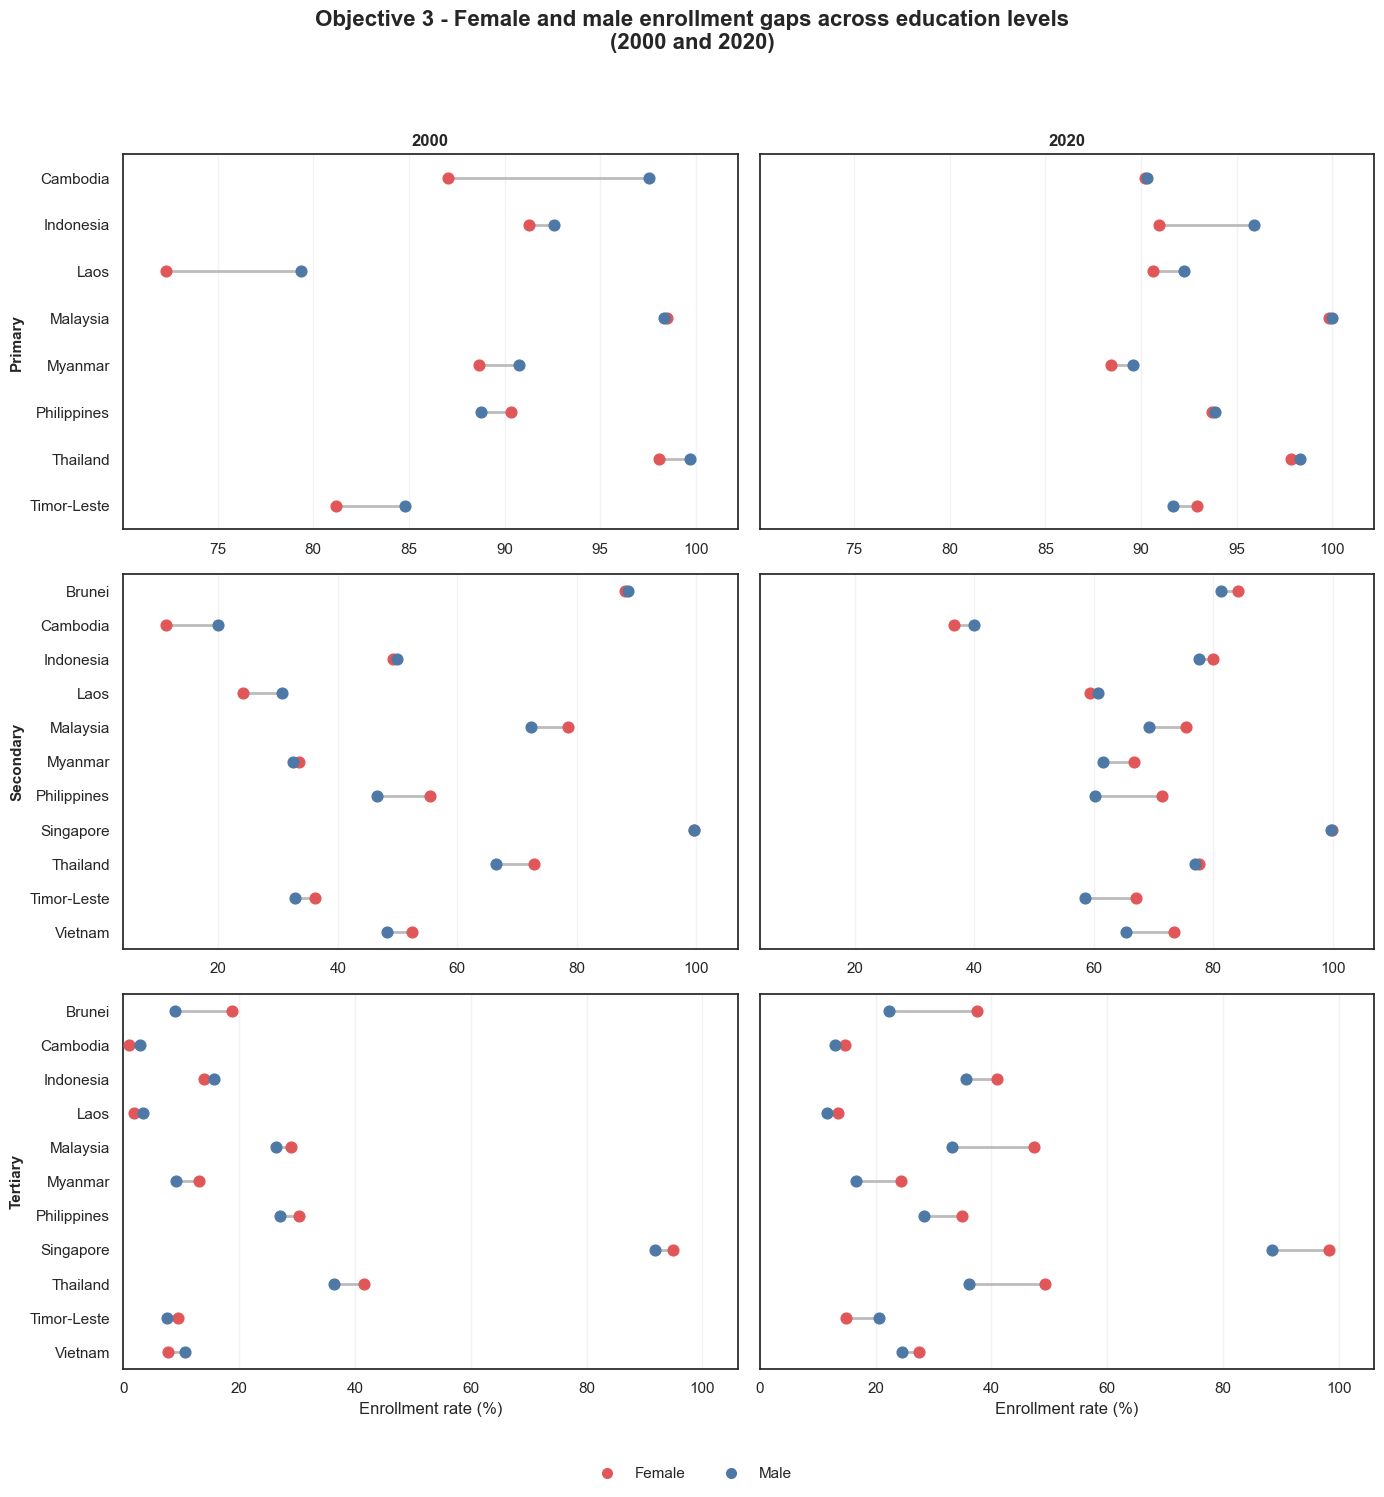

In [53]:
# Chart 1: Dumbbell plots for female-male enrollment gaps across 2000 and 2020
EXCLUDED_COUNTRIES = ["Brunei Darussalam", "Singapore", "Viet Nam"]
EXCLUDED_DISPLAY_COUNTRIES = [display_names.get(c, c) for c in EXCLUDED_COUNTRIES]
PRIMARY_COUNTRY_ORDER = [c for c in country_order if c not in EXCLUDED_DISPLAY_COUNTRIES]

dumbbell_specs = [
    (
        OBJ3_COLS["primary_female"],
        OBJ3_COLS["primary_male"],
        "Primary",
    ),
    (
        OBJ3_COLS["secondary_female"],
        OBJ3_COLS["secondary_male"],
        "Secondary",
    ),
    (
        OBJ3_COLS["tertiary_female"],
        OBJ3_COLS["tertiary_male"],
        "Tertiary",
    ),
]

female_color = "#E15759"
male_color = "#4E79A7"

x_limits = {}
for female_col, male_col, level_name in dumbbell_specs:
    limit_df = obj3_selected[["Country", female_col, male_col]].copy()

    if level_name == "Primary":
        limit_df = limit_df[~limit_df["Country"].isin(EXCLUDED_DISPLAY_COUNTRIES)]

    vals = pd.concat(
        [limit_df[female_col], limit_df[male_col]],
        ignore_index=True,
    ).dropna()

    x_min = vals.min()
    x_max = vals.max()
    x_pad = (x_max - x_min) * 0.08 if x_max > x_min else 2
    x_limits[(female_col, male_col)] = (max(0, x_min - x_pad), x_max + x_pad)

fig, axes = plt.subplots(3, 2, figsize=(14, 15))
fig.patch.set_facecolor("white")

for row, (female_col, male_col, level_name) in enumerate(dumbbell_specs):
    x_left, x_right = x_limits[(female_col, male_col)]
    current_country_order = PRIMARY_COUNTRY_ORDER if level_name == "Primary" else country_order

    for col, year in enumerate(SELECTED_YEARS):
        ax = axes[row, col]

        plot_df = obj3_selected.loc[
            obj3_selected["Year"].eq(year),
            ["Country", female_col, male_col],
        ].dropna().copy()

        if level_name == "Primary":
            plot_df = plot_df[~plot_df["Country"].isin(EXCLUDED_DISPLAY_COUNTRIES)].copy()

        plot_df["Country"] = pd.Categorical(
            plot_df["Country"],
            categories=current_country_order,
            ordered=True,
        )
        plot_df = plot_df.sort_values("Country")
        plot_df["y"] = plot_df["Country"].cat.codes

        ax.hlines(
            y=plot_df["y"],
            xmin=plot_df[[female_col, male_col]].min(axis=1),
            xmax=plot_df[[female_col, male_col]].max(axis=1),
            color="#B5B5B5",
            linewidth=2,
            alpha=0.9,
        )
        ax.scatter(plot_df[female_col], plot_df["y"], color=female_color, s=60, zorder=3)
        ax.scatter(plot_df[male_col], plot_df["y"], color=male_color, s=60, zorder=3)

        ax.set_xlim(x_left, x_right)
        ax.set_ylim(-0.5, len(current_country_order) - 0.5)
        ax.invert_yaxis()

        if row == 0:
            ax.set_title(str(year), fontsize=12, weight="bold")

        if col == 0:
            ax.set_ylabel(level_name, fontsize=11, weight="bold")
            ax.set_yticks(range(len(current_country_order)))
            ax.set_yticklabels(current_country_order)
        else:
            ax.set_ylabel("")
            ax.set_yticks(range(len(current_country_order)))
            ax.set_yticklabels([])

        if row == 2:
            ax.set_xlabel("Enrollment rate (%)")

        ax.grid(axis="x", alpha=0.25)
        ax.set_axisbelow(True)

handles = [
    Line2D([0], [0], marker="o", color="w", markerfacecolor=female_color, markersize=9, label="Female"),
    Line2D([0], [0], marker="o", color="w", markerfacecolor=male_color, markersize=9, label="Male"),
]

fig.legend(
    handles=handles,
    loc="lower center",
    ncol=2,
    frameon=False,
    bbox_to_anchor=(0.5, -0.01),
)

fig.suptitle(
    "Objective 3 - Female and male enrollment gaps across education levels\n(2000 and 2020)",
    fontsize=16,
    weight="bold",
    y=0.98,
)

plt.tight_layout(rect=(0, 0.03, 1, 0.95))
plt.show()


- **Overview analysis:**
  - The dumbbell plots show that the **gender gap is smallest at the primary level**, becomes more visible at the **secondary level**, and is **strongest at the tertiary level**.
  - In general, **primary education is close to gender parity** in both 2000 and 2020, while higher education shows wider differences between female and male enrollment.
  - By 2020, the gender gap in many countries tends to shift **in favor of females**, especially at the secondary and tertiary levels.

- **Observations and trends drawn from the data:**
  - At the **primary level**, most countries are clustered near high enrollment rates, especially in 2020, which suggests that gender disparity in basic access is relatively small.
  - Some countries such as **Cambodia** and **Laos** show a clear male advantage in 2000 at the primary level, but this gap becomes much smaller by 2020.
  - At the **secondary level**, the gender pattern is more mixed. Several countries, such as **Malaysia, the Philippines, Thailand, Timor-Leste, and Viet Nam**, show higher female enrollment than male enrollment.
  - A few countries, such as **Cambodia** and **Laos**, still show either male advantage or near parity at the secondary level, indicating that gender progress is not uniform across the region.
  - At the **tertiary level**, the gender gap is the most pronounced. In most countries, **female enrollment is higher than male enrollment**, and the distance between the two points is clearly larger than in primary or secondary education.
  - The strongest female advantages in tertiary education appear in countries such as **Brunei, Malaysia, Singapore, and Thailand** in 2020.
  - Although tertiary participation increases in many countries between 2000 and 2020, the gains are not always balanced between genders, so wider gaps remain visible at this level.

- **Conclusion:**
  - Overall, the figure suggests that **gender parity is mostly achieved in primary education**, while **secondary and especially tertiary education show more noticeable disparities**.
  - The **largest gender gap appears at the tertiary level**, where female enrollment is often substantially higher than male enrollment.
  - This means that equality in foundational education does not always remain unchanged at higher levels, and gender imbalance becomes more evident as education level rises.


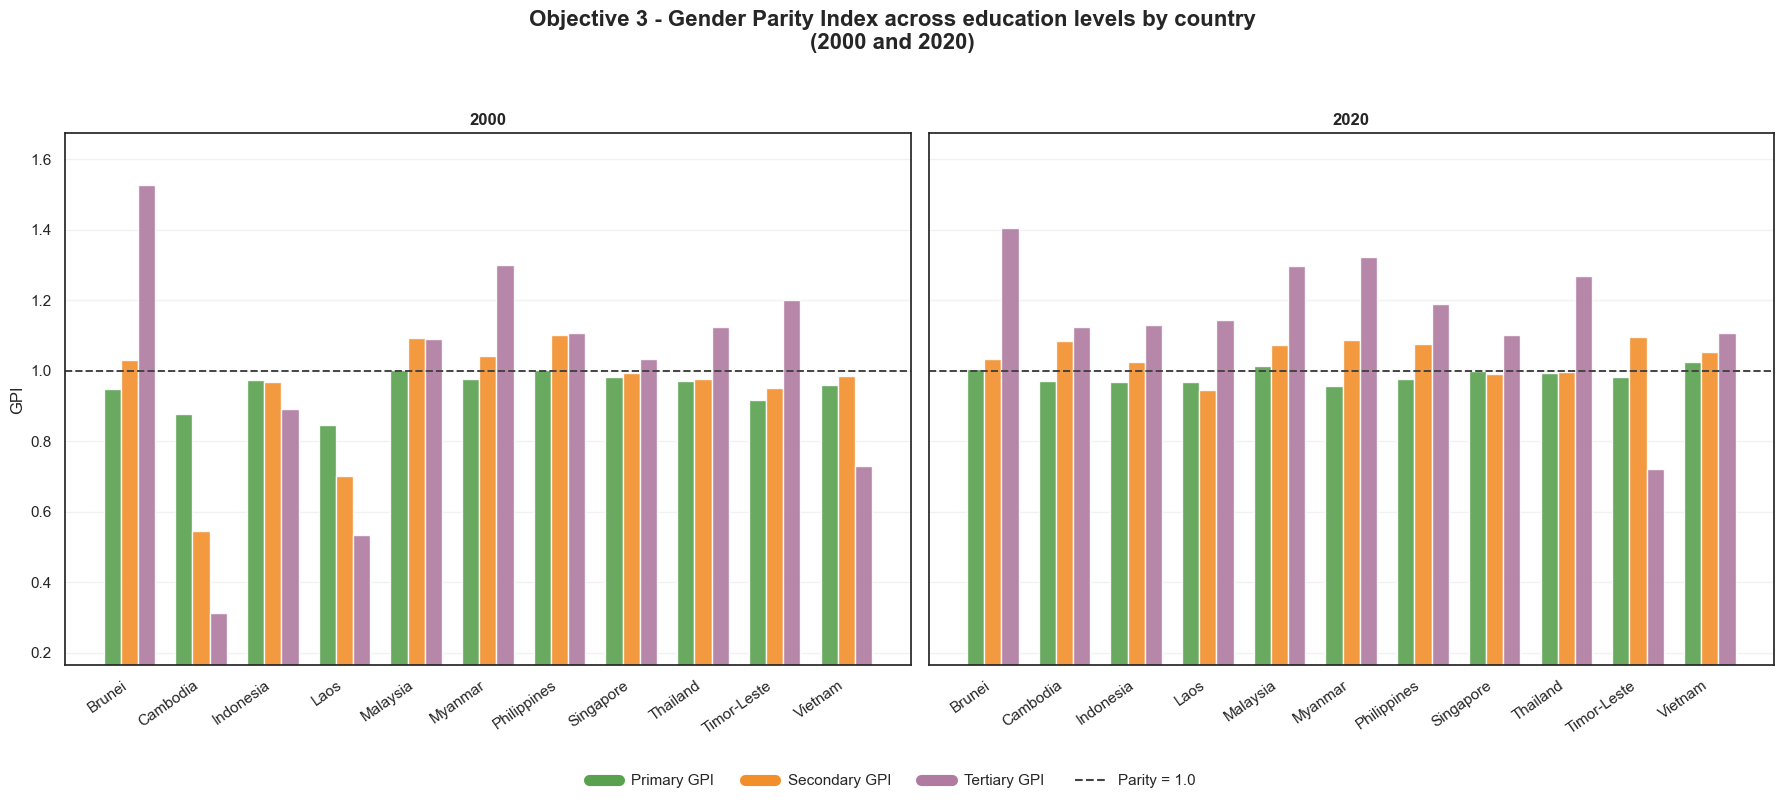

In [54]:
# Chart 2: Grouped bar charts for GPI across 2000 and 2020

gpi_specs = [
    (OBJ3_COLS["primary_gpi"], "Primary GPI", "#59A14F"),
    (OBJ3_COLS["secondary_gpi"], "Secondary GPI", "#F28E2B"),
    (OBJ3_COLS["tertiary_gpi"], "Tertiary GPI", "#B07AA1"),
]

gpi_values = obj3_selected[[spec[0] for spec in gpi_specs]].to_numpy(dtype=float)
gpi_min = np.nanmin(gpi_values)
gpi_max = np.nanmax(gpi_values)
gpi_pad = (gpi_max - gpi_min) * 0.12 if gpi_max > gpi_min else 0.1

fig, axes = plt.subplots(1, 2, figsize=(18, 8), sharey=True)
width = 0.24

for ax, year in zip(axes, SELECTED_YEARS):
    gpi_df = obj3_selected.loc[
        obj3_selected["Year"].eq(year),
        ["Country"] + [spec[0] for spec in gpi_specs],
    ].copy()

    gpi_df["Country"] = pd.Categorical(gpi_df["Country"], categories=country_order, ordered=True)
    gpi_df = gpi_df.sort_values("Country")

    x = np.arange(len(gpi_df))

    for i, (col, label, color) in enumerate(gpi_specs):
        ax.bar(
            x + (i - 1) * width,
            gpi_df[col],
            width=width,
            label=label,
            color=color,
            alpha=0.9,
        )

    ax.axhline(1.0, color="#444444", linestyle="--", linewidth=1.4)
    ax.set_ylim(max(0, gpi_min - gpi_pad), gpi_max + gpi_pad)
    ax.set_title(str(year), fontsize=12, weight="bold")
    ax.set_xticks(x)
    ax.set_xticklabels(gpi_df["Country"], rotation=35, ha="right")
    ax.grid(axis="y", alpha=0.25)
    ax.set_axisbelow(True)

axes[0].set_ylabel("GPI")

legend_handles = [
    Line2D([0], [0], color="#59A14F", lw=8, label="Primary GPI"),
    Line2D([0], [0], color="#F28E2B", lw=8, label="Secondary GPI"),
    Line2D([0], [0], color="#B07AA1", lw=8, label="Tertiary GPI"),
    Line2D([0], [0], color="#444444", lw=1.5, linestyle="--", label="Parity = 1.0"),
]

fig.legend(
    handles=legend_handles,
    loc="lower center",
    ncol=4,
    frameon=False,
    bbox_to_anchor=(0.5, -0.01),
)

fig.suptitle(
    "Objective 3 - Gender Parity Index across education levels by country\n(2000 and 2020)",
    fontsize=16,
    weight="bold",
    y=0.98,
)

plt.tight_layout(rect=(0, 0.05, 1, 0.95))
plt.show()


- **Overview analysis:**
  - The grouped bar charts show that **gender parity is closest at the primary level**, becomes more varied at the **secondary level**, and is **most uneven at the tertiary level**.
  - In both 2000 and 2020, most countries have **primary GPI values close to 1.0**, while tertiary GPI displays the largest deviations from parity.
  - By 2020, several countries moved closer to parity in primary and secondary education, but strong differences still remain in higher education.

- **Observations and trends drawn from the data:**
  - At the **primary level**, almost all countries have GPI values near `1.0`, indicating that gender balance in basic education is generally well maintained across the region.
  - At the **secondary level**, most countries also stay relatively close to parity, though some cases show a moderate female advantage, especially by 2020.
  - The **tertiary level** shows the largest variation across countries and across time, making it the level where gender disparity is strongest.
  - Several countries, such as **Brunei, Myanmar, Thailand, Malaysia, and the Philippines**, have tertiary GPI values clearly above `1.0`, meaning female participation in tertiary education is higher than male participation.
  - In contrast, countries such as **Cambodia** and **Timor-Leste** have tertiary GPI values well below `1.0`, indicating that males remain more represented than females at this level.
  - Between 2000 and 2020, countries like **Cambodia, Laos, and Indonesia** show visible improvement in tertiary GPI, moving closer to or above parity.
  - However, the tertiary pattern is still far less balanced than the primary and secondary patterns, which suggests that parity at lower levels does not always continue into higher education.

- **Conclusion:**
  - Overall, the charts confirm that **gender parity is strongest in primary education and weakest in tertiary education**.
  - The main imbalance in Southeast Asia is not basic schooling, but rather **access to higher education**, where countries differ much more clearly.
  - This means that many countries have achieved near-equal access at lower levels, but **gender disparities remain or reappear at the tertiary level**.


#### Objective 4: Monitoring youth literacy rates and gender disparities in foundational learning outcomes

- **Question** Do countries with high levels of educational access, especially in secondary and tertiary education, also tend to have high youth literacy rates?

- **Data fields**  
  - `Literacy rate, youth total (% of people ages 15-24)`: measures the share of young people who can read and write with understanding, used as the main indicator of foundational learning outcomes.  
  - `Literacy rate, youth female (% of females ages 15-24)`: measures literacy outcomes specifically for young women.  
  - `Literacy rate, youth male (% of males ages 15-24)`: measures literacy outcomes specifically for young men.  
  - `Literacy rate, youth (ages 15-24), gender parity index (GPI)`: shows the ratio of female youth literacy to male youth literacy, where `1.0` indicates gender parity.  
  - `School enrollment, secondary (% net)`: measures access to secondary education, used to test whether higher school participation is associated with stronger youth literacy outcomes.  
  - `School enrollment, tertiary (% gross)`: measures access to tertiary education, used as another indicator of educational participation for comparison with literacy outcomes.

In [55]:
OBJ4_COLS = {
    "youth_total": "Literacy rate, youth total (% of people ages 15-24)",
    "youth_gpi": "Literacy rate, youth (ages 15-24), gender parity index (GPI)",
    "secondary_net": "School enrollment, secondary (% net)",
    "tertiary_gross": "School enrollment, tertiary (% gross)",
}

obj4_df = data[data["Country Name"].isin(SEA_COUNTRIES)].copy()
obj4_df["Year"] = pd.to_numeric(obj4_df["Year"], errors="coerce")

for col in OBJ4_COLS.values():
    obj4_df[col] = pd.to_numeric(obj4_df[col], errors="coerce")

obj4_df = obj4_df[obj4_df["Year"].between(2000, 2020)].copy()

obj4_display_names = {
    "Brunei Darussalam": "Brunei",
    "Lao PDR": "Laos",
    "Viet Nam": "Vietnam",
}
obj4_country_order = [obj4_display_names.get(country, country) for country in SEA_COUNTRIES]
obj4_df["Country"] = obj4_df["Country Name"].replace(obj4_display_names)

obj4_palette = dict(
    zip(obj4_country_order, sns.color_palette("tab20", n_colors=len(obj4_country_order)))
)

- **Chart type**  
  - **Scatterplot**: suitable for visualizing the relationship between educational access and youth literacy. By placing indicators such as `School enrollment, secondary (% net)` or `School enrollment, tertiary (% gross)` on the x-axis and `Literacy rate, youth total (% of people ages 15-24)` on the y-axis, the chart helps reveal whether countries with stronger educational access also tend to achieve stronger foundational learning outcomes.

- **Expected insight**  This analysis is expected to identify countries where school participation is relatively high but literacy outcomes are not equally strong, suggesting that access to education does not always guarantee learning quality. 


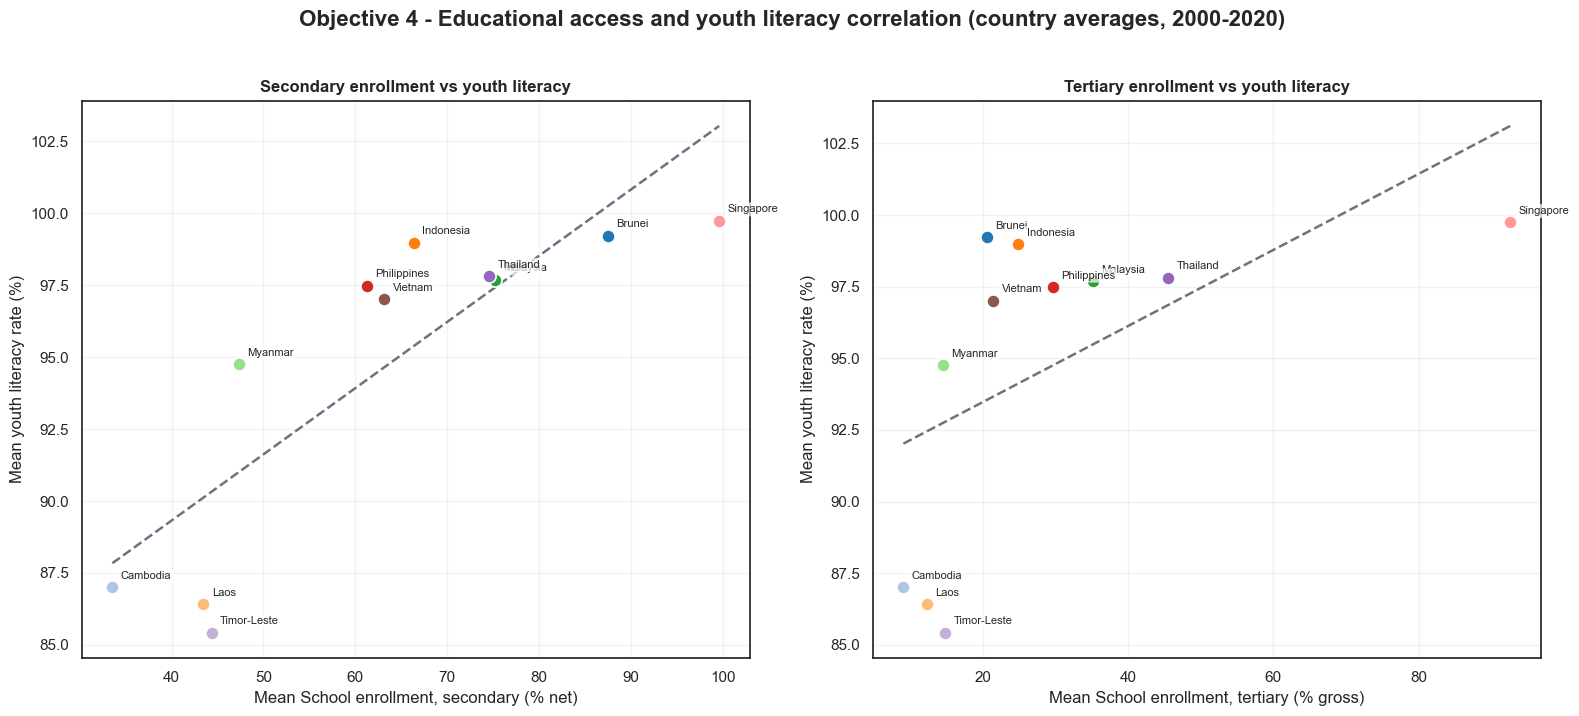

In [56]:
# Chart: Scatterplots for educational access and youth literacy
obj4_corr = (
    obj4_df.groupby("Country", as_index=False)[
        [OBJ4_COLS["secondary_net"], OBJ4_COLS["tertiary_gross"], OBJ4_COLS["youth_total"]]
    ]
    .mean(numeric_only=True)
)

scatter_specs = [
    (OBJ4_COLS["secondary_net"], "Secondary enrollment vs youth literacy"),
    (OBJ4_COLS["tertiary_gross"], "Tertiary enrollment vs youth literacy"),
]

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

for ax, (x_col, title) in zip(axes, scatter_specs):
    plot_df = obj4_corr[["Country", x_col, OBJ4_COLS["youth_total"]]].dropna().copy()

    sns.regplot(
        data=plot_df,
        x=x_col,
        y=OBJ4_COLS["youth_total"],
        scatter=False,
        ci=None,
        line_kws={"color": "#6B7280", "linestyle": "--", "linewidth": 1.8},
        ax=ax,
    )

    for _, row in plot_df.iterrows():
        country = row["Country"]
        ax.scatter(
            row[x_col],
            row[OBJ4_COLS["youth_total"]],
            s=90,
            color=obj4_palette[country],
            edgecolor="white",
            linewidth=1.2,
            zorder=3,
        )
        ax.annotate(
            country,
            (row[x_col], row[OBJ4_COLS["youth_total"]]),
            xytext=(6, 6),
            textcoords="offset points",
            fontsize=8,
            bbox=dict(boxstyle="round,pad=0.18", fc="white", ec="none", alpha=0.72),
        )

    ax.set_title(title, fontsize=12, weight="bold")
    ax.set_xlabel(f"Mean {x_col}")
    ax.set_ylabel("Mean youth literacy rate (%)")
    ax.grid(alpha=0.25)

fig.suptitle(
    "Objective 4 - Educational access and youth literacy correlation (country averages, 2000-2020)",
    fontsize=16,
    weight="bold",
    y=1.02,
)
plt.tight_layout()
plt.show()


- **Overview analysis:**
  - The scatterplots suggest a **positive relationship** between educational access and youth literacy across Southeast Asian countries.
  - Countries with **higher secondary or tertiary enrollment** generally also show **higher youth literacy rates**, although the relationship is stronger in some cases than others.
  - At the same time, the plots also show that **high enrollment does not always guarantee equally high literacy**, so educational access and learning outcomes are related but not identical.

- **Observations and trends drawn from the data:**
  - Countries such as **Singapore, Brunei, Thailand, Malaysia, and Indonesia** appear in the upper-right area of the plots, indicating both relatively high school participation and high youth literacy.
  - **Singapore** stands out with the highest combination of enrollment and literacy, especially in the tertiary-enrollment comparison.
  - **Cambodia, Laos, and Timor-Leste** appear in the lower-left area of the charts, showing lower average enrollment and lower youth literacy than the regional leaders.
  - **Myanmar** occupies a middle position, with moderate enrollment and literacy outcomes that are below the strongest-performing countries but above the weakest group.
  - In the **secondary enrollment vs youth literacy** plot, the upward pattern is fairly clear, suggesting that countries with broader access to secondary education tend to have stronger foundational literacy outcomes among youth.
  - In the **tertiary enrollment vs youth literacy** plot, the relationship remains positive, but the spread is wider. Some countries achieve high youth literacy even with only moderate tertiary enrollment, implying that strong foundational learning may depend more directly on earlier education stages than on university participation.

- **Conclusion:**
  - Overall, the figure indicates that **better educational access is generally associated with higher youth literacy** in Southeast Asia.
  - However, the relationship is **not perfectly linear**, which suggests that school participation alone is not sufficient to explain literacy outcomes.
  - This means that while expanding access is important, **education quality and learning effectiveness** also play a major role in shaping youth literacy.


#### Objective 5: Long-term educational attainment and gender disparities among the adult population

- **Question**  
  How does the overall educational attainment of the adult population aged `25+` differ across Southeast Asian countries? Is the gender gap consistent across higher education levels such as `Bachelor’s`, `Master’s`, and `Doctoral` degrees?

- **Data fields**  
  - `Educational attainment, at least completed primary, population 25+ years, total (%)`: measures the share of adults aged `25+` who have completed at least primary education, used as a baseline indicator of basic educational attainment.  
  - `Educational attainment, at least completed upper secondary, population 25+, total (%)`: measures the share of adults aged `25+` who have completed at least upper secondary education, used to compare intermediate educational achievement across countries.  
  - `Educational attainment, at least Bachelor's or equivalent, population 25+, total (%)`: measures the overall share of adults with at least a Bachelor’s degree or equivalent.  
  - `Educational attainment, at least Bachelor's or equivalent, population 25+, female (%)`: measures the share of adult women with at least a Bachelor’s degree or equivalent.  
  - `Educational attainment, at least Bachelor's or equivalent, population 25+, male (%)`: measures the share of adult men with at least a Bachelor’s degree or equivalent.  
  - `Educational attainment, at least Master's or equivalent, population 25+, total (%)`: measures the overall share of adults with at least a Master’s degree or equivalent.  
  - `Educational attainment, at least Master's or equivalent, population 25+, female (%)`: measures the share of adult women with at least a Master’s degree or equivalent.  
  - `Educational attainment, at least Master's or equivalent, population 25+, male (%)`: measures the share of adult men with at least a Master’s degree or equivalent.  
  - `Educational attainment, Doctoral or equivalent, population 25+, total (%)`: measures the overall share of adults with a Doctoral degree or equivalent.  
  - `Educational attainment, Doctoral or equivalent, population 25+, female (%)`: measures the share of adult women with a Doctoral degree or equivalent.  
  - `Educational attainment, Doctoral or equivalent, population 25+, male (%)`: measures the share of adult men with a Doctoral degree or equivalent.


In [57]:
SELECTED_YEARS = [2000, 2020]

OBJ5_COLS = {
    "primary_total": "Educational attainment, at least completed primary, population 25+ years, total (%) (cumulative)",
    "upper_secondary_total": "Educational attainment, at least completed upper secondary, population 25+, total (%) (cumulative)",
    "bachelor_total": "Educational attainment, at least Bachelor's or equivalent, population 25+, total (%) (cumulative)",
    "bachelor_female": "Educational attainment, at least Bachelor's or equivalent, population 25+, female (%) (cumulative)",
    "bachelor_male": "Educational attainment, at least Bachelor's or equivalent, population 25+, male (%) (cumulative)",
    "master_total": "Educational attainment, at least Master's or equivalent, population 25+, total (%) (cumulative)",
    "master_female": "Educational attainment, at least Master's or equivalent, population 25+, female (%) (cumulative)",
    "master_male": "Educational attainment, at least Master's or equivalent, population 25+, male (%) (cumulative)",
    "doctoral_total": "Educational attainment, Doctoral or equivalent, population 25+, total (%) (cumulative)",
    "doctoral_female": "Educational attainment, Doctoral or equivalent, population 25+, female (%) (cumulative)",
    "doctoral_male": "Educational attainment, Doctoral or equivalent, population 25+, male (%) (cumulative)",
}

obj5_df = data[data["Country Name"].isin(SEA_COUNTRIES)].copy()
obj5_df["Year"] = pd.to_numeric(obj5_df["Year"], errors="coerce")

for col in OBJ5_COLS.values():
    obj5_df[col] = pd.to_numeric(obj5_df[col], errors="coerce")

display_names = {
    "Brunei Darussalam": "Brunei",
    "Lao PDR": "Laos",
    "Viet Nam": "Vietnam",
}
country_order = [display_names.get(country, country) for country in SEA_COUNTRIES]

obj5_selected = obj5_df.loc[
    obj5_df["Year"].isin(SELECTED_YEARS),
    ["Country Name", "Year"] + list(OBJ5_COLS.values()),
].copy()

obj5_selected["Country"] = obj5_selected["Country Name"].replace(display_names)
obj5_selected["Country"] = pd.Categorical(
    obj5_selected["Country"],
    categories=country_order,
    ordered=True,
)

- **Chart type**  
  - **Horizontal bar chart**: suitable for comparing the overall educational attainment of adults across countries in a snapshot year such as `2020`. By sorting countries from highest to lowest, the chart makes it easy to compare and rank national achievement levels.  
  - **Dumbbell plot (or paired bar chart)**: suitable for visualizing the gender gap in higher education attainment at the `Bachelor's`, `Master's`, and `Doctoral` levels. By placing male and female values on the same axis and connecting them with a line, the chart highlights both the direction and magnitude of gender disparities.

- **Expected insight**  
  This analysis is expected to show which countries have the strongest overall educational attainment among adults and whether higher levels of education are distributed equally between men and women. It can also reveal whether the gender gap remains similar across different higher-education levels or becomes wider at more advanced academic stages.

- **Note on missing values**  
  Some indicators in this objective still contain missing values and should be interpreted carefully when a related country appears in the analysis.  
  - **No imputation was applied** to indicators in this objective.  
  - In this objective, we will not display `Singapore` and `Timor-Leste` in `Master's` and `Doctoral` attainment analysis at the second chart, because the following indicators are missing for the full period `2000-2020`


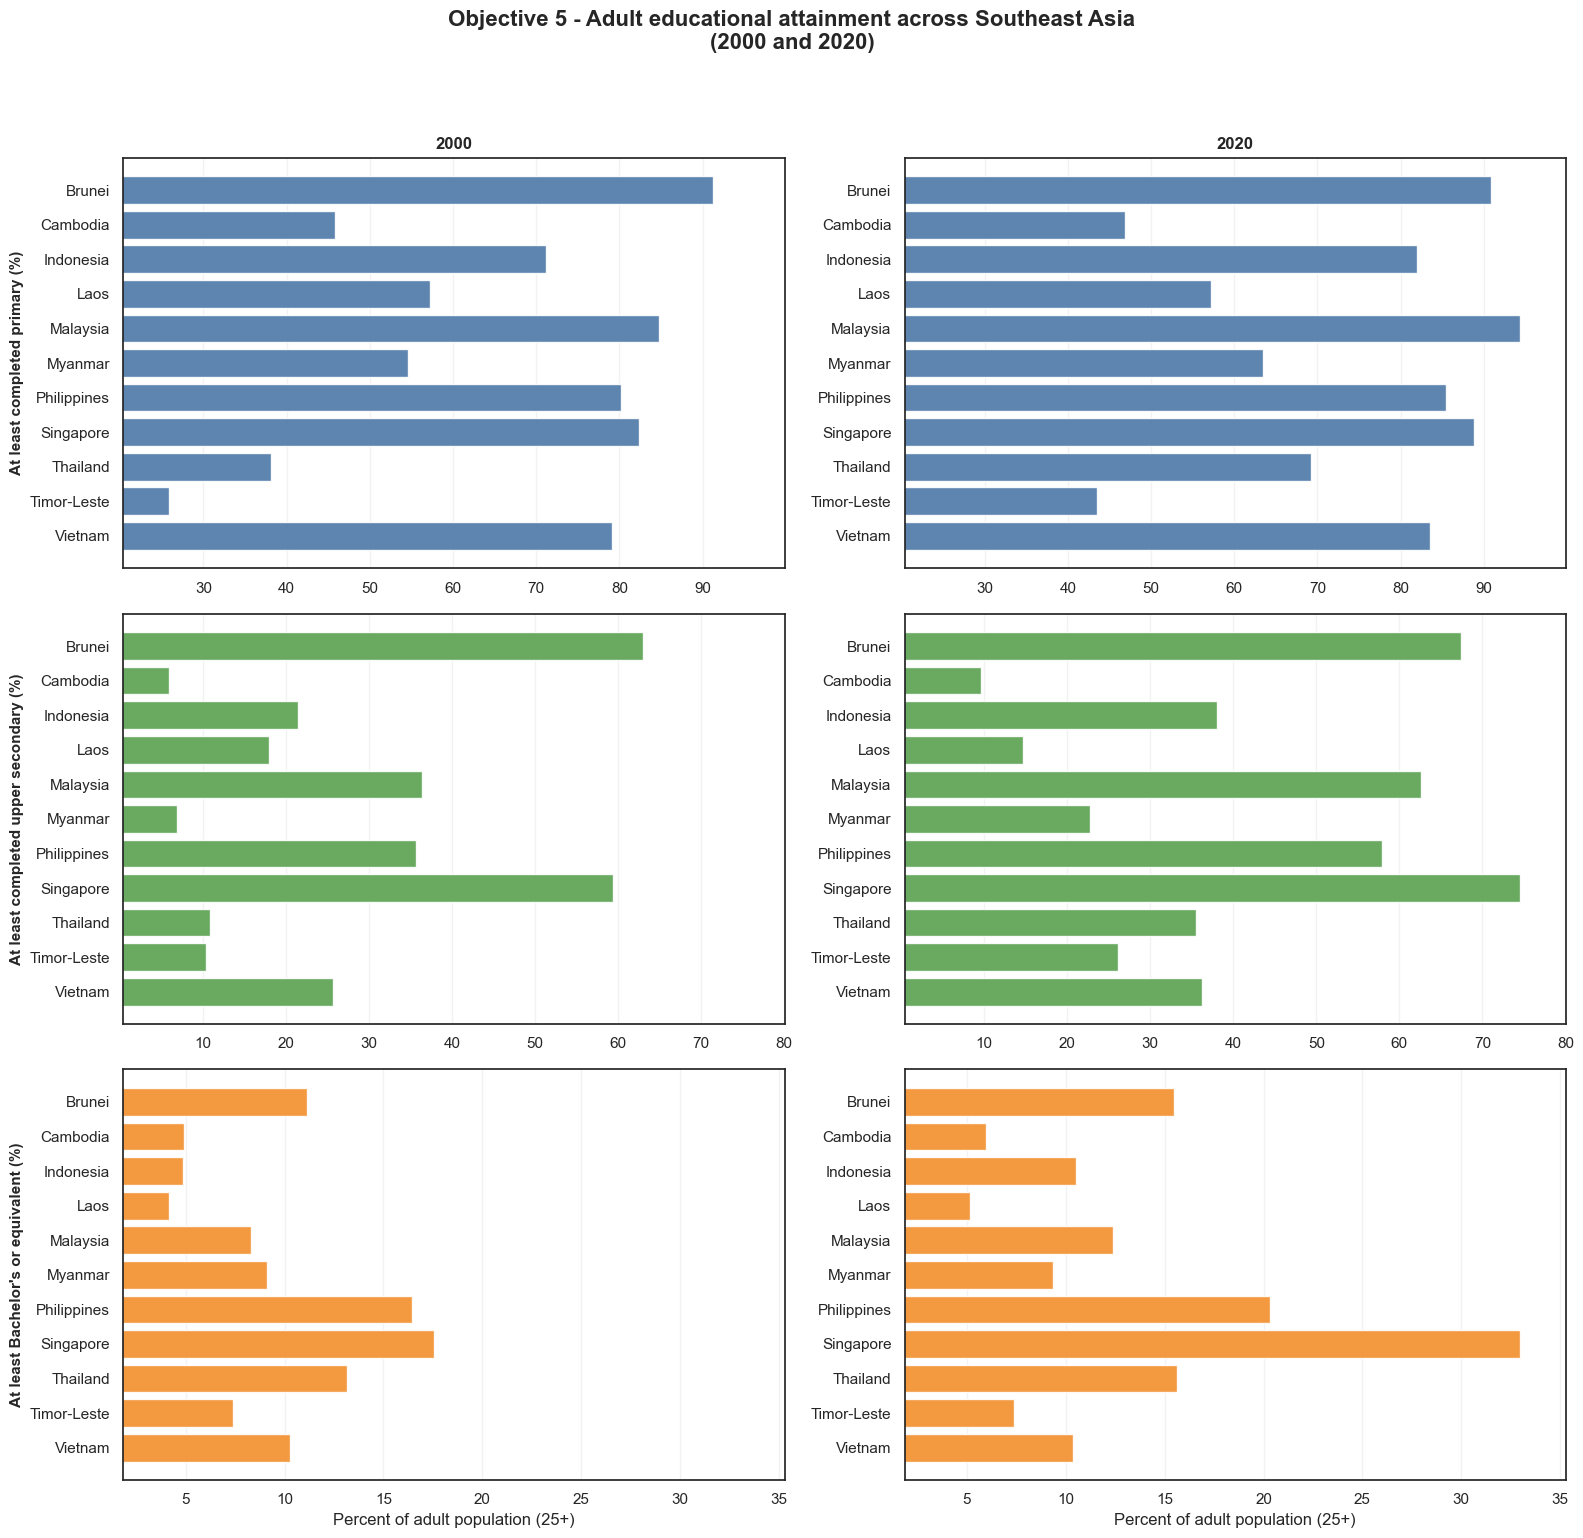

In [58]:
# Chart 1: Horizontal bar charts for overall educational attainment in 2000 and 2020
bar_specs = [
    (OBJ5_COLS["primary_total"], "At least completed primary (%)", "#4C78A8"),
    (OBJ5_COLS["upper_secondary_total"], "At least completed upper secondary (%)", "#59A14F"),
    (OBJ5_COLS["bachelor_total"], "At least Bachelor's or equivalent (%)", "#F28E2B"),
]

x_limits = {}
for col, _, _ in bar_specs:
    vals = obj5_selected[col].dropna()
    x_min = vals.min()
    x_max = vals.max()
    x_pad = (x_max - x_min) * 0.08 if x_max > x_min else 2
    x_limits[col] = (max(0, x_min - x_pad), x_max + x_pad)

fig, axes = plt.subplots(3, 2, figsize=(16, 16))
fig.patch.set_facecolor("white")

for row, (col, title, color) in enumerate(bar_specs):
    x_left, x_right = x_limits[col]

    for col_idx, year in enumerate(SELECTED_YEARS):
        ax = axes[row, col_idx]

        plot_df = obj5_selected.loc[
            obj5_selected["Year"].eq(year),
            ["Country", col],
        ].dropna().copy()

        plot_df["Country"] = pd.Categorical(plot_df["Country"], categories=country_order, ordered=True)
        plot_df = plot_df.sort_values("Country")

        ax.barh(plot_df["Country"], plot_df[col], color=color, alpha=0.9)
        ax.invert_yaxis()
        ax.set_xlim(x_left, x_right)

        if row == 0:
            ax.set_title(str(year), fontsize=12, weight="bold")

        if col_idx == 0:
            ax.set_ylabel(title, fontsize=11, weight="bold")
        else:
            ax.set_ylabel("")

        if row == 2:
            ax.set_xlabel("Percent of adult population (25+)")

        ax.grid(axis="x", alpha=0.25)
        ax.set_axisbelow(True)

fig.suptitle(
    "Objective 5 - Adult educational attainment across Southeast Asia\n(2000 and 2020)",
    fontsize=16,
    weight="bold",
    y=0.98,
)

plt.tight_layout(rect=(0, 0.02, 1, 0.95))
plt.show()


- **Overview analysis:**
  - Adult educational attainment improved across most Southeast Asian countries between **2000 and 2020** at all three levels shown: **completed primary**, **completed upper secondary**, and **at least Bachelor's or equivalent**.
  - Countries with stronger education systems, such as **Singapore, Brunei, and Malaysia**, generally remain at the top across all attainment levels.
  - The gap between countries is still clear, but many lower-performing countries also show visible progress over time.

- **Observations and trends drawn from the data:**
  - For **at least completed primary education**, most countries already had relatively high levels in 2000 and continued to improve by 2020.
  - **Brunei, Malaysia, Singapore, the Philippines, and Vietnam** are among the strongest performers in primary attainment by 2020, while **Timor-Leste, Cambodia, and Laos** remain lower despite improvement.
  - For **at least completed upper secondary education**, cross-country differences are larger. **Singapore, Brunei, Malaysia, and the Philippines** stand out with much higher attainment than the rest of the region.
  - Several countries, such as **Indonesia, Thailand, Vietnam, Myanmar, and Timor-Leste**, show progress in upper-secondary completion, but they still remain below the leading group.
  - The widest differences appear in **Bachelor's or equivalent attainment**. **Singapore** is the clear regional leader by 2020, followed by countries such as the **Philippines, Thailand, Brunei, and Malaysia**.
  - Lower-income countries such as **Cambodia, Laos, and Timor-Leste** continue to have much smaller shares of adults with higher education, even though gradual improvement is visible.

- **Conclusion:**
  - Overall, the figure shows that **adult educational attainment increased across the region** from 2000 to 2020. Progress is visible at all levels, but the **regional gap becomes wider at higher levels of education**, especially at the Bachelor's level. This suggests that while access to basic and secondary education has expanded, **advanced educational attainment remains unevenly distributed across Southeast Asia**.


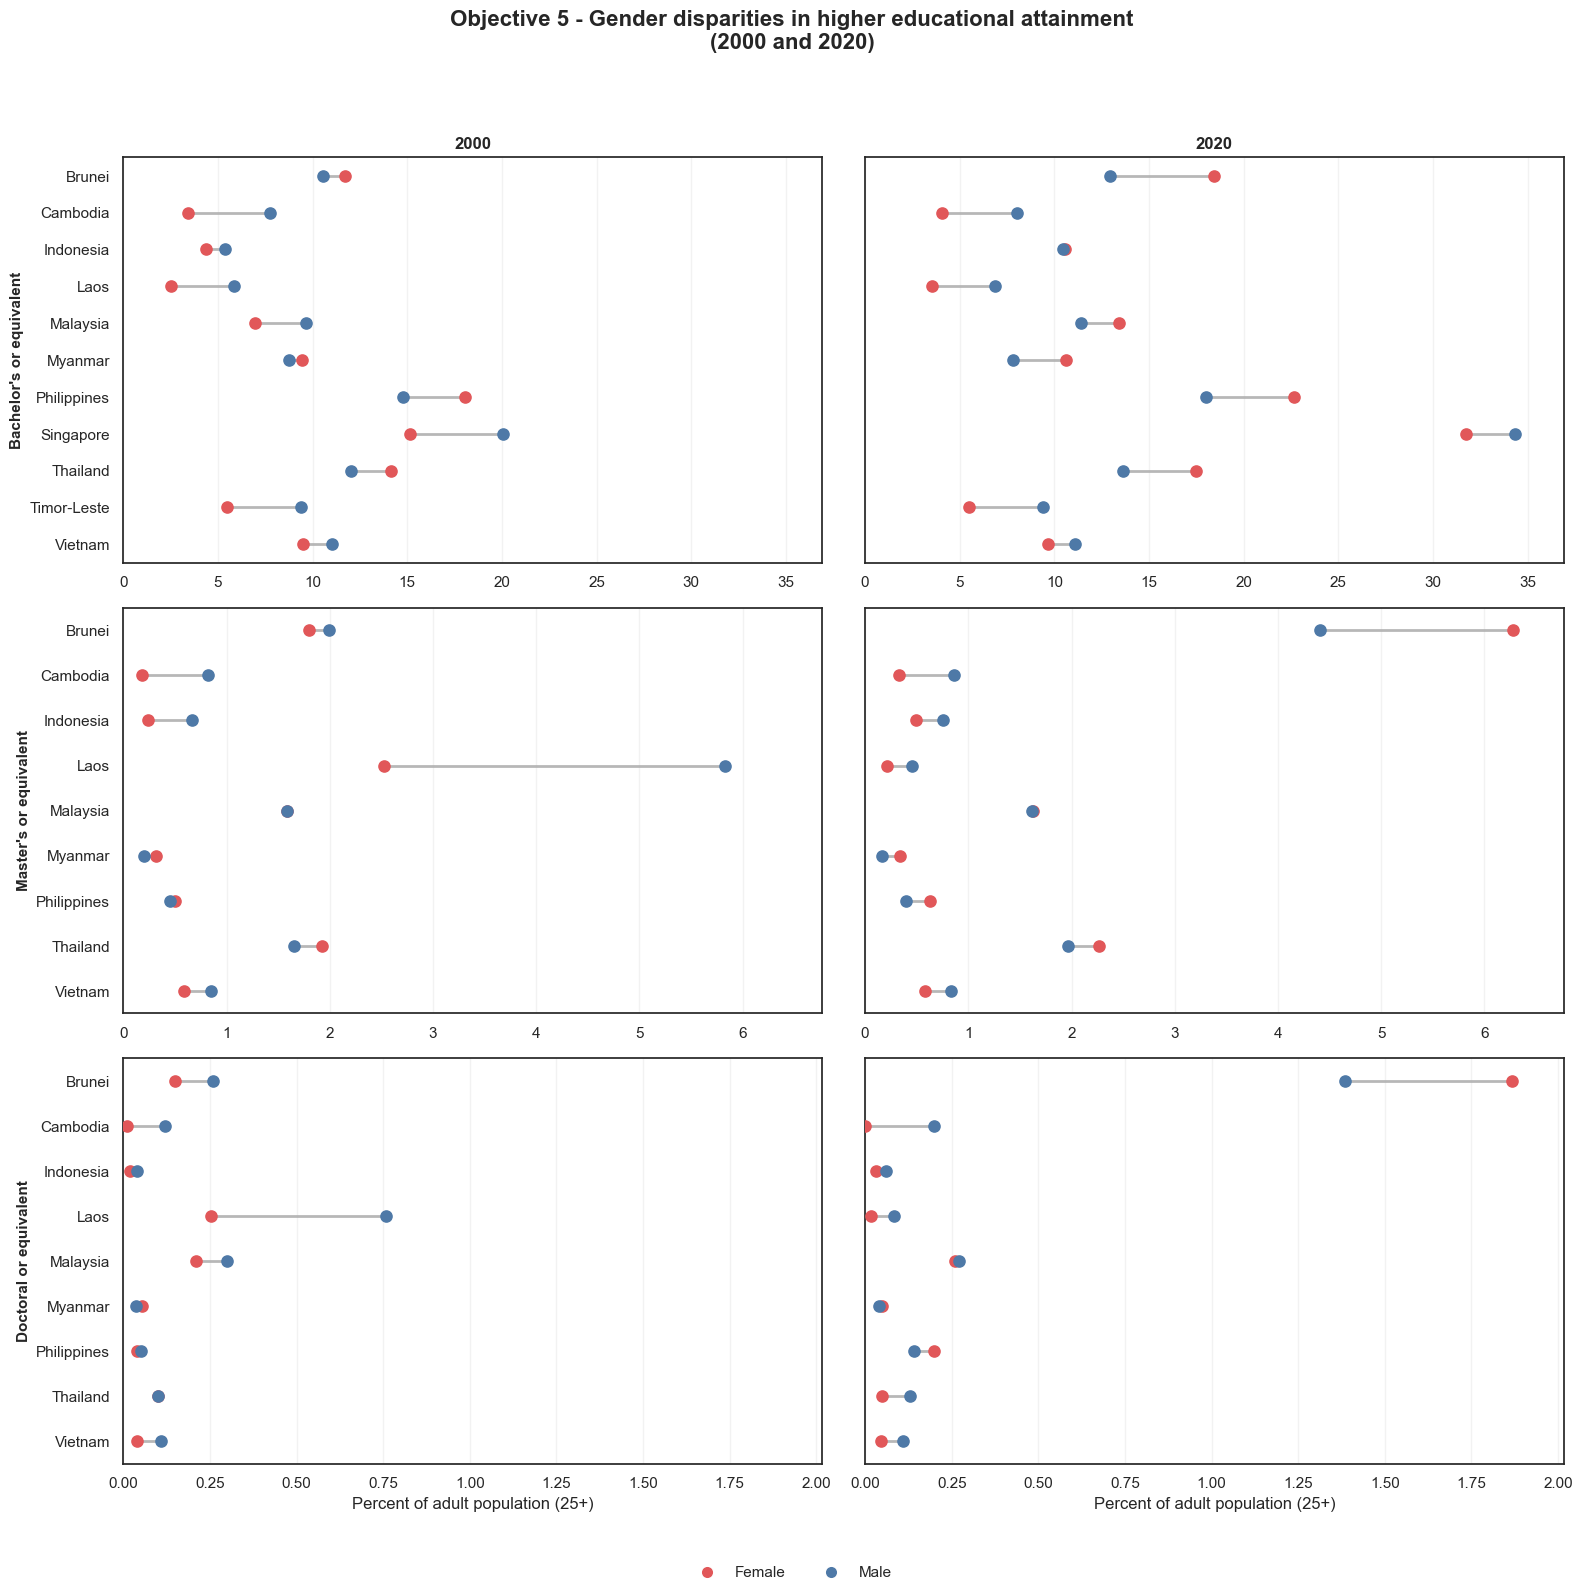

In [59]:
# Chart 2: Dumbbell plots for gender gaps in higher education in 2000 and 2020
EXCLUDED_COUNTRIES = ["Singapore", "Timor-Leste"]

dumbbell_specs = [
    (
        OBJ5_COLS["bachelor_female"],
        OBJ5_COLS["bachelor_male"],
        "Bachelor's or equivalent",
        [],
    ),
    (
        OBJ5_COLS["master_female"],
        OBJ5_COLS["master_male"],
        "Master's or equivalent",
        EXCLUDED_COUNTRIES,
    ),
    (
        OBJ5_COLS["doctoral_female"],
        OBJ5_COLS["doctoral_male"],
        "Doctoral or equivalent",
        EXCLUDED_COUNTRIES,
    ),
]

female_color = "#E15759"
male_color = "#4E79A7"

x_limits = {}
for female_col, male_col, _, excluded in dumbbell_specs:
    limit_df = obj5_selected[["Country", female_col, male_col]].copy()

    if excluded:
        limit_df = limit_df[~limit_df["Country"].isin(excluded)]

    vals = pd.concat(
        [limit_df[female_col], limit_df[male_col]],
        ignore_index=True,
    ).dropna()

    x_min = vals.min()
    x_max = vals.max()
    x_pad = (x_max - x_min) * 0.08 if x_max > x_min else 1
    x_limits[(female_col, male_col)] = (max(0, x_min - x_pad), x_max + x_pad)

fig, axes = plt.subplots(3, 2, figsize=(16, 16))
fig.patch.set_facecolor("white")

for row, (female_col, male_col, title, excluded) in enumerate(dumbbell_specs):
    x_left, x_right = x_limits[(female_col, male_col)]
    current_country_order = [c for c in country_order if c not in excluded]

    for col_idx, year in enumerate(SELECTED_YEARS):
        ax = axes[row, col_idx]

        plot_df = obj5_selected.loc[
            obj5_selected["Year"].eq(year),
            ["Country", female_col, male_col],
        ].dropna().copy()

        if excluded:
            plot_df = plot_df[~plot_df["Country"].isin(excluded)].copy()

        plot_df["Country"] = pd.Categorical(
            plot_df["Country"],
            categories=current_country_order,
            ordered=True,
        )
        plot_df = plot_df.sort_values("Country")
        plot_df["y"] = plot_df["Country"].cat.codes

        ax.hlines(
            y=plot_df["y"],
            xmin=plot_df[[female_col, male_col]].min(axis=1),
            xmax=plot_df[[female_col, male_col]].max(axis=1),
            color="#B0B0B0",
            linewidth=2,
            alpha=0.9,
        )
        ax.scatter(plot_df[female_col], plot_df["y"], color=female_color, s=65, zorder=3)
        ax.scatter(plot_df[male_col], plot_df["y"], color=male_color, s=65, zorder=3)

        ax.set_xlim(x_left, x_right)
        ax.set_ylim(-0.5, len(current_country_order) - 0.5)
        ax.invert_yaxis()

        if row == 0:
            ax.set_title(str(year), fontsize=12, weight="bold")

        if col_idx == 0:
            ax.set_ylabel(title, fontsize=11, weight="bold")
            ax.set_yticks(range(len(current_country_order)))
            ax.set_yticklabels(current_country_order)
        else:
            ax.set_ylabel("")
            ax.set_yticks(range(len(current_country_order)))
            ax.set_yticklabels([])

        if row == 2:
            ax.set_xlabel("Percent of adult population (25+)")

        ax.grid(axis="x", alpha=0.25)
        ax.set_axisbelow(True)

handles = [
    Line2D([0], [0], marker="o", color="w", markerfacecolor=female_color, markersize=9, label="Female"),
    Line2D([0], [0], marker="o", color="w", markerfacecolor=male_color, markersize=9, label="Male"),
]

fig.legend(
    handles=handles,
    loc="lower center",
    ncol=2,
    frameon=False,
    bbox_to_anchor=(0.5, -0.01),
)

fig.suptitle(
    "Objective 5 - Gender disparities in higher educational attainment\n(2000 and 2020)",
    fontsize=16,
    weight="bold",
    y=0.98,
)

plt.tight_layout(rect=(0, 0.03, 1, 0.95))
plt.show()


- **Overview analysis:**
  - The dumbbell plots show that gender disparities in higher educational attainment vary across both countries and degree levels.
  - In general, the gender gap is relatively moderate at the **Bachelor's** level, but becomes more uneven at the **Master's** and **Doctoral** levels.
  - Between 2000 and 2020, higher educational attainment increased in many countries, but the direction of the gender gap is not consistent across the region.

- **Observations and trends drawn from the data:**
  - At the **Bachelor's level**, several countries such as **Brunei, Malaysia, Myanmar, and the Philippines** show higher female attainment than male attainment, especially in 2020.
  - In contrast, countries such as **Singapore, Cambodia, Laos, and Timor-Leste** show either a male advantage or a smaller gap at the Bachelor's level.
  - At the **Master's level**, disparities become more visible. Some countries, such as **Brunei** and **Thailand**, show a female advantage by 2020, while others such as **Cambodia, Indonesia, Laos, and Vietnam** still show higher male attainment.
  - The **Doctoral level** has the lowest attainment overall, but also shows clear gender imbalance in several countries.
  - In **Brunei**, the female share at the Doctoral level is notably higher than the male share by 2020, while in countries such as **Cambodia, Laos, and Vietnam**, men remain slightly ahead.
  - Some countries, such as **Malaysia** and **Myanmar**, appear closer to parity at advanced levels, while others continue to show stronger gender separation.
  - Overall, the gender gap does not follow one common regional pattern: in some countries women are more represented in higher education, while in others men still lead, especially at more advanced degrees.

- **Conclusion:**
  - The figure suggests that **gender disparity in higher educational attainment is country-specific and degree-specific**, rather than uniform across Southeast Asia.
  - The **Bachelor's level** often shows the broadest participation, while **Master's** and especially **Doctoral** attainment remain much smaller and more uneven.
  - This means that progress in higher education does not automatically imply gender equality, and disparities may persist or even widen at more advanced academic levels.
